## 1. Installation et Imports

In [1]:
# Installation des dépendances (à exécuter une seule fois)
# !pip install faiss-cpu numpy matplotlib -q

In [2]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
from typing import Tuple, List, Dict

# Chemins
DATA_PATH = "./data/"
RESULTS_PATH = "./results/"

print(f"FAISS version: {faiss.__version__}")
print(f"NumPy version: {np.__version__}")
import os
os.makedirs(RESULTS_PATH, exist_ok=True)
print("Dossier results/ pret")

FAISS version: 1.13.0
NumPy version: 2.0.2


## 2. Chargement du Dataset SIFT1M

Le dataset SIFT1M contient :
- **Base** : 1M vecteurs (128 dim)
- **Query** : 10k vecteurs de requête
- **Ground Truth** : 100 vrais voisins par requête

In [3]:
def read_fvecs(filename: str) -> np.ndarray:
    """
    Charge un fichier .fvecs (vecteurs float32).
    Format: [dim, v1, v2, ..., v_dim] répété pour chaque vecteur
    """
    with open(filename, 'rb') as f:
        # Lire la dimension
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
        f.seek(0)
        
        # Calculer le nombre de vecteurs
        file_size = os.path.getsize(filename)
        vec_size = 4 + d * 4  # 4 bytes (dim) + d * 4 bytes (floats)
        n_vectors = file_size // vec_size
        
        # Lire tous les vecteurs
        data = np.fromfile(f, dtype=np.int32, count=n_vectors * (d + 1))
        data = data.reshape(-1, d + 1)
        
        # Extraire les vecteurs (ignorer première colonne)
        vectors = data[:, 1:].view(dtype=np.float32)
    
    return vectors

def read_ivecs(filename: str) -> np.ndarray:
    """
    Charge un fichier .ivecs (vecteurs int32).
    """
    with open(filename, 'rb') as f:
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
        f.seek(0)
        
        file_size = os.path.getsize(filename)
        vec_size = 4 + d * 4
        n_vectors = file_size // vec_size
        
        data = np.fromfile(f, dtype=np.int32, count=n_vectors * (d + 1))
        data = data.reshape(-1, d + 1)
        vectors = data[:, 1:]
    
    return vectors

def load_sift1m(data_dir: str = './data') -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Charge le dataset SIFT1M complet.
    """
    print("Chargement du dataset SIFT1M...")
    
    base_file = os.path.join(data_dir, 'sift_base.fvecs')
    query_file = os.path.join(data_dir, 'sift_query.fvecs')
    gt_file = os.path.join(data_dir, 'sift_groundtruth.ivecs')
    
    base_vectors = read_fvecs(base_file)
    query_vectors = read_fvecs(query_file)
    ground_truth = read_ivecs(gt_file)
    
    print(f"  Base vectors: {base_vectors.shape}")
    print(f"  Query vectors: {query_vectors.shape}")
    print(f"  Ground truth: {ground_truth.shape}")
    
    return base_vectors, query_vectors, ground_truth

In [4]:
# Chargement des données SIFT1M
try:
    base_vectors, query_vectors, ground_truth = load_sift1m(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset SIFT1M introuvable dans '{DATA_PATH}'.\n"
        "Crée le dossier Valentin/data/ et place-y les fichiers :\n"
        "  - sift_base.fvecs\n"
        "  - sift_query.fvecs\n"
        "  - sift_groundtruth.ivecs\n"
        "Téléchargement : ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
    )

Chargement du dataset SIFT1M...
  Base vectors: (1000000, 128)
  Query vectors: (10000, 128)
  Ground truth: (10000, 100)


### Aide rapide: verifier le dataset SIFT1M

## 3. Module de Métriques

Fonctions pour évaluer les performances :
- **Recall@K** : Précision des résultats
- **QPS** : Requêtes par seconde
- **Latence** : Temps par requête (ms)
- **Mémoire** : Taille de l'index

In [5]:
def calculate_recall_at_k(predictions: np.ndarray, ground_truth: np.ndarray, k: int = 10) -> float:
    """
    Calcul du Recall@K.
    
    Args:
        predictions: (n_queries, k) indices prédits
        ground_truth: (n_queries, k_gt) vrais indices
        k: nombre de voisins à considérer
    """
    n_queries = predictions.shape[0]
    recalls = []
    
    for i in range(n_queries):
        pred_set = set(predictions[i, :k])
        true_set = set(ground_truth[i, :k])
        
        intersection = len(pred_set.intersection(true_set))
        recall = intersection / k
        recalls.append(recall)
    
    return np.mean(recalls)

def measure_query_time(index, query_vectors: np.ndarray, k: int = 10, n_runs: int = 3):
    """
    Mesure le temps de requête moyen.
    """
    n_queries = query_vectors.shape[0]
    
    # Warmup
    _, _ = index.search(query_vectors[:100], k)
    
    # Mesure
    times = []
    for _ in range(n_runs):
        start = time.time()
        D, I = index.search(query_vectors, k)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    qps = n_queries / avg_time
    latency_ms = (avg_time / n_queries) * 1000
    
    return qps, latency_ms, (D, I)

def estimate_index_size(index) -> float:
    """
    Estime la taille mémoire de l'index en Mo.
    """
    if hasattr(index, 'nlist') and hasattr(index, 'pq'):
        d = index.d
        nlist = index.nlist
        m = index.pq.M
        ntotal = index.ntotal
        
        # Taille des centroïdes
        centroids_size = nlist * d * 4
        # Taille des codes PQ
        codes_size = ntotal * m
        # Taille totale
        size_bytes = centroids_size + codes_size
    else:
        size_bytes = sys.getsizeof(index)
    
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

In [7]:
# Créer le coarse quantizer (pour la partition IVF)
quantizer = faiss.IndexFlatL2(d)

# Créer l'index IVF-PQ
index_ivfpq = faiss.IndexIVFPQ(quantizer, d, nlist, m, nbits)

print(f"✓ Index IVF-PQ créé")
print(f"  Type: {type(index_ivfpq).__name__}")
print(f"  Is trained: {index_ivfpq.is_trained}")

✓ Index IVF-PQ créé
  Type: IndexIVFPQ
  Is trained: False


In [ ]:
# Entraînement de l'index
# Échantillon aléatoire de 100k vecteurs (reproductible, seed=42)

train_size = 100000
rng = np.random.default_rng(42)
idx_train = rng.choice(base_vectors.shape[0], size=train_size, replace=False)
train_data = base_vectors[idx_train].copy()

print(f"Entraînement sur {train_size} vecteurs (échantillon aléatoire, seed=42)...")
start_time = time.time()

index_ivfpq.train(train_data)

train_time = time.time() - start_time
print(f"✓ Entraînement terminé en {train_time:.2f} secondes")
print(f"  Is trained: {index_ivfpq.is_trained}")

In [9]:
# Ajout des vecteurs de base à l'index

print(f"📥 Ajout de {base_vectors.shape[0]} vecteurs...")
start_time = time.time()

index_ivfpq.add(base_vectors)

add_time = time.time() - start_time
print(f"✓ Vecteurs ajoutés en {add_time:.2f} secondes")
print(f"  Vecteurs indexés: {index_ivfpq.ntotal}")

build_time_total = train_time + add_time
print(f"\n⏱️  Temps total de construction: {build_time_total:.2f} secondes")

📥 Ajout de 1000000 vecteurs...
✓ Vecteurs ajoutés en 1.78 secondes
  Vecteurs indexés: 1000000

⏱️  Temps total de construction: 4.66 secondes


## 5. Benchmark du Paramètre nprobe

**nprobe** contrôle le trade-off précision/vitesse :
- nprobe = 1 : Rapide mais peu précis
- nprobe ↑ : Plus précis mais plus lent

In [10]:
# Tester différentes valeurs de nprobe

nprobe_values = [1, 2, 5, 10, 20, 50, 100, 200]
k = 10  # nombre de voisins à chercher

results_nprobe = []

print(f"📊 Benchmark nprobe (k={k})\n")
print(f"{'nprobe':>8} {'Recall@10':>12} {'Latence(ms)':>14} {'QPS':>10}")
print("="*50)

for nprobe in nprobe_values:
    index_ivfpq.nprobe = nprobe
    
    # Mesurer performances
    qps, latency_ms, (D, I) = measure_query_time(index_ivfpq, query_vectors, k=k)
    
    # Calculer recall
    recall = calculate_recall_at_k(I, ground_truth, k=k)
    
    result = {
        'nprobe': nprobe,
        'recall': recall,
        'qps': qps,
        'latency_ms': latency_ms
    }
    results_nprobe.append(result)
    
    print(f"{nprobe:8d} {recall:12.4f} {latency_ms:14.2f} {qps:10.1f}")

# Mesurer la mémoire (constante pour cet index)
memory_mb = estimate_index_size(index_ivfpq)
print(f"\n💾 Empreinte mémoire: {memory_mb:.2f} Mo")

📊 Benchmark nprobe (k=10)

  nprobe    Recall@10    Latence(ms)        QPS
       1       0.2359           0.00   493501.7
       2       0.2936           0.00   415300.9
       5       0.3470           0.00   284141.9
      10       0.3660           0.01   170770.7
      20       0.3734           0.01   101331.1
      50       0.3755           0.02    46880.9
     100       0.3756           0.04    24535.6
     200       0.3756           0.07    13428.2

💾 Empreinte mémoire: 8.13 Mo


## 6. Visualisations

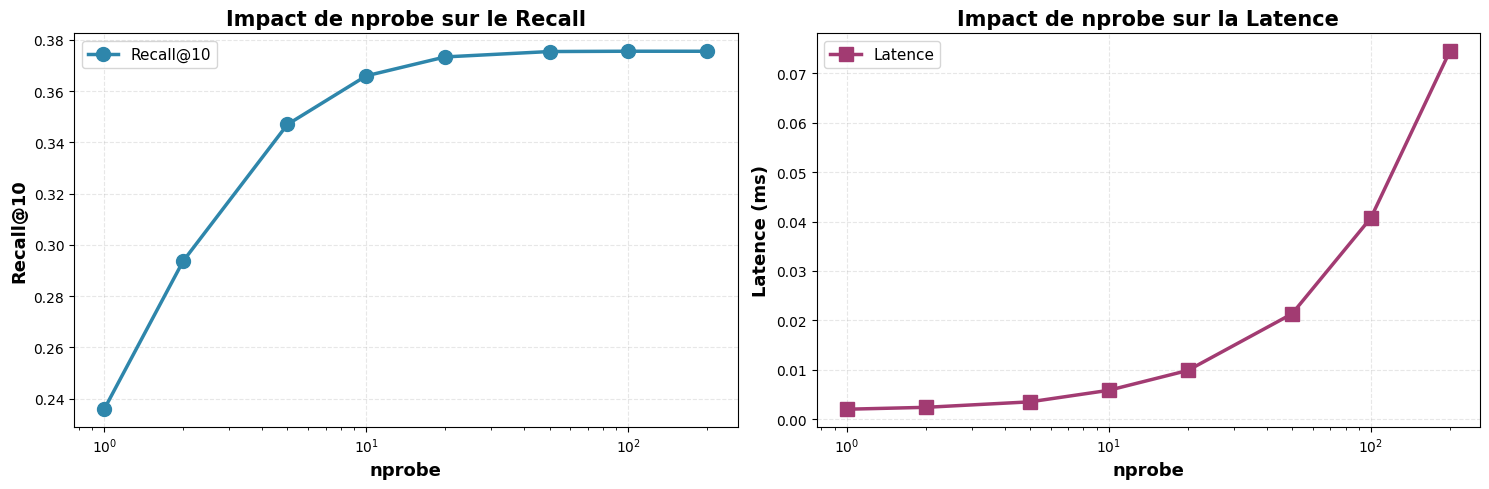

✓ Graphique sauvegardé: ivfpq_nprobe_impact.png


In [11]:
# Graphique 1: Impact de nprobe sur Recall et Latence

nprobe_list = [r['nprobe'] for r in results_nprobe]
recall_list = [r['recall'] for r in results_nprobe]
latency_list = [r['latency_ms'] for r in results_nprobe]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Recall vs nprobe
ax1.plot(nprobe_list, recall_list, 'o-', linewidth=2.5, markersize=10, 
         color='#2E86AB', label='Recall@10')
ax1.set_xlabel('nprobe', fontsize=13, fontweight='bold')
ax1.set_ylabel('Recall@10', fontsize=13, fontweight='bold')
ax1.set_title('Impact de nprobe sur le Recall', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xscale('log')
ax1.legend(fontsize=11)

# Latence vs nprobe
ax2.plot(nprobe_list, latency_list, 's-', linewidth=2.5, markersize=10, 
         color='#A23B72', label='Latence')
ax2.set_xlabel('nprobe', fontsize=13, fontweight='bold')
ax2.set_ylabel('Latence (ms)', fontsize=13, fontweight='bold')
ax2.set_title('Impact de nprobe sur la Latence', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xscale('log')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('results/ivfpq_nprobe_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_nprobe_impact.png")

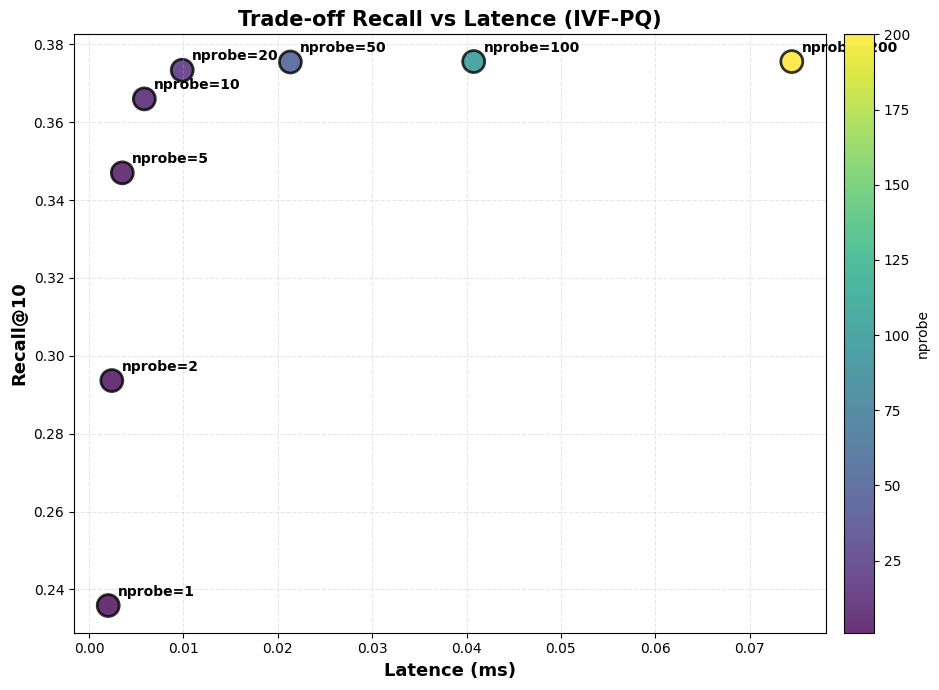

✓ Graphique sauvegardé: ivfpq_recall_latency.png


In [12]:
# Graphique 2: Trade-off Recall vs Latence

plt.figure(figsize=(10, 7))

scatter = plt.scatter(latency_list, recall_list, c=nprobe_list, 
                     cmap='viridis', s=250, alpha=0.8, 
                     edgecolors='black', linewidth=2)

# Annotations
for i, np_val in enumerate(nprobe_list):
    plt.annotate(f'nprobe={np_val}', 
                (latency_list[i], recall_list[i]),
                xytext=(7, 7), textcoords='offset points', 
                fontsize=10, fontweight='bold')

plt.colorbar(scatter, label='nprobe', pad=0.02)
plt.xlabel('Latence (ms)', fontsize=13, fontweight='bold')
plt.ylabel('Recall@10', fontsize=13, fontweight='bold')
plt.title('Trade-off Recall vs Latence (IVF-PQ)', 
         fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/ivfpq_recall_latency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_recall_latency.png")

## 7. Comparaison de Différentes Valeurs de nlist

Test de l'impact du nombre de cellules Voronoi

In [13]:
# Tester différentes valeurs de nlist

nlist_values = [256, 512, 1024, 2048]
nprobe_fixed = 10  # valeur fixe de nprobe pour la comparaison

results_nlist = []

print(f"📊 Benchmark nlist (nprobe={nprobe_fixed}, m={m})\n")
print(f"{'nlist':>8} {'Build(s)':>12} {'Recall@10':>12} {'Latence(ms)':>14} {'Memory(Mo)':>13}")
print("="*65)

for nlist_val in nlist_values:
    # Créer nouvel index
    quantizer_temp = faiss.IndexFlatL2(d)
    index_temp = faiss.IndexIVFPQ(quantizer_temp, d, nlist_val, m, nbits)
    
    # Entraîner et ajouter
    start = time.time()
    index_temp.train(train_data)
    index_temp.add(base_vectors)
    build_time = time.time() - start
    
    # Tester avec nprobe fixe
    index_temp.nprobe = nprobe_fixed
    
    qps, latency_ms, (D, I) = measure_query_time(index_temp, query_vectors, k=10)
    recall = calculate_recall_at_k(I, ground_truth, k=10)
    memory = estimate_index_size(index_temp)
    
    result = {
        'nlist': nlist_val,
        'build_time': build_time,
        'recall': recall,
        'latency_ms': latency_ms,
        'memory_mb': memory
    }
    results_nlist.append(result)
    
    print(f"{nlist_val:8d} {build_time:12.2f} {recall:12.4f} {latency_ms:14.2f} {memory:13.2f}")

📊 Benchmark nlist (nprobe=10, m=8)

   nlist     Build(s)    Recall@10    Latence(ms)    Memory(Mo)
     256         3.55       0.3558           0.02          7.75
     512         3.92       0.3628           0.01          7.88
    1024         4.52       0.3660           0.01          8.13
    2048         5.65       0.3635           0.00          8.63


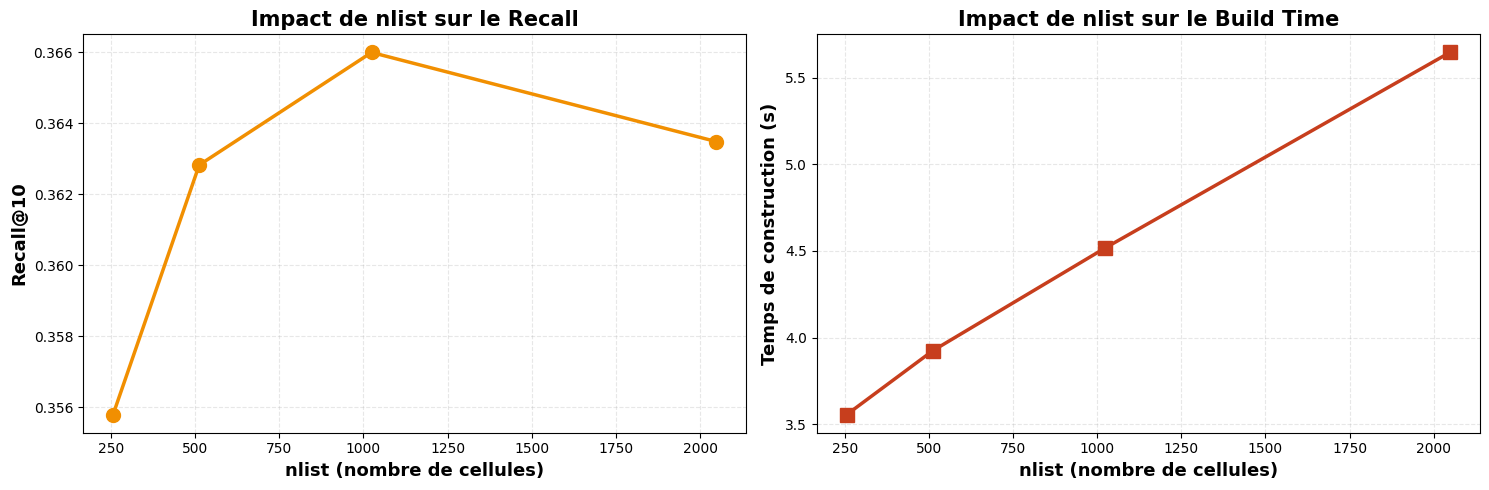

✓ Graphique sauvegardé: ivfpq_nlist_impact.png


In [14]:
# Visualisation impact de nlist

nlist_plot = [r['nlist'] for r in results_nlist]
recall_nlist = [r['recall'] for r in results_nlist]
build_nlist = [r['build_time'] for r in results_nlist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Recall vs nlist
ax1.plot(nlist_plot, recall_nlist, 'o-', linewidth=2.5, markersize=10, color='#F18F01')
ax1.set_xlabel('nlist (nombre de cellules)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Recall@10', fontsize=13, fontweight='bold')
ax1.set_title('Impact de nlist sur le Recall', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Build time vs nlist
ax2.plot(nlist_plot, build_nlist, 's-', linewidth=2.5, markersize=10, color='#C73E1D')
ax2.set_xlabel('nlist (nombre de cellules)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Temps de construction (s)', fontsize=13, fontweight='bold')
ax2.set_title('Impact de nlist sur le Build Time', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/ivfpq_nlist_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_nlist_impact.png")

## 8. Résumé des Résultats

In [15]:
# Résumé final

print("="*70)
print("  RÉSUMÉ FINAL - IVF-PQ BENCHMARK")
print("="*70)

# Meilleur recall
best_recall = max(results_nprobe, key=lambda x: x['recall'])
print(f"\n🏆 Configuration pour meilleur Recall:")
print(f"  nprobe = {best_recall['nprobe']}")
print(f"  Recall@10 = {best_recall['recall']:.4f} ({best_recall['recall']*100:.2f}%)")
print(f"  Latence = {best_recall['latency_ms']:.2f} ms")
print(f"  QPS = {best_recall['qps']:.1f}")

# Meilleure vitesse avec recall > 0.5
fast_results = [r for r in results_nprobe if r['recall'] > 0.5]
if fast_results:
    fastest = min(fast_results, key=lambda x: x['latency_ms'])
    print(f"\n⚡ Configuration la plus rapide (Recall > 50%):")
    print(f"  nprobe = {fastest['nprobe']}")
    print(f"  Recall@10 = {fastest['recall']:.4f} ({fastest['recall']*100:.2f}%)")
    print(f"  Latence = {fastest['latency_ms']:.2f} ms")
    print(f"  QPS = {fastest['qps']:.1f}")

print(f"\n💾 Empreinte mémoire: {memory_mb:.2f} Mo")
print(f"⏱️  Temps de construction: {build_time_total:.2f} secondes")

print(f"\n📁 Fichiers générés:")
print(f"  - ivfpq_nprobe_impact.png")
print(f"  - ivfpq_recall_latency.png")
print(f"  - ivfpq_nlist_impact.png")

print("\n✅ Benchmark IVF-PQ terminé avec succès!")
print("="*70)

  RÉSUMÉ FINAL - IVF-PQ BENCHMARK

🏆 Configuration pour meilleur Recall:
  nprobe = 100
  Recall@10 = 0.3756 (37.56%)
  Latence = 0.04 ms
  QPS = 24535.6

💾 Empreinte mémoire: 8.13 Mo
⏱️  Temps de construction: 4.66 secondes

📁 Fichiers générés:
  - ivfpq_nprobe_impact.png
  - ivfpq_recall_latency.png
  - ivfpq_nlist_impact.png

✅ Benchmark IVF-PQ terminé avec succès!


## 9. Sauvegarde des Résultats en CSV

In [16]:
import pandas as pd

# Sauvegarder résultats nprobe
df_nprobe = pd.DataFrame(results_nprobe)
df_nprobe.to_csv('results/ivfpq_nprobe_results.csv', index=False)
print("✓ Sauvegardé: ivfpq_nprobe_results.csv")

# Sauvegarder résultats nlist
df_nlist = pd.DataFrame(results_nlist)
df_nlist.to_csv('results/ivfpq_nlist_results.csv', index=False)
print("✓ Sauvegardé: ivfpq_nlist_results.csv")

# Afficher preview
print("\n📊 Preview résultats nprobe:")
display(df_nprobe)

print("\n📊 Preview résultats nlist:")
display(df_nlist)

✓ Sauvegardé: ivfpq_nprobe_results.csv
✓ Sauvegardé: ivfpq_nlist_results.csv

📊 Preview résultats nprobe:


,nprobe,recall,qps,latency_ms
0,1,0.23585,493501.717836,0.002026
1,2,0.29364,415300.924474,0.002408
2,5,0.34700,284141.911620,0.003519
3,10,0.36599,170770.665186,0.005856
4,20,0.37337,101331.108538,0.009869
5,50,0.37547,46880.877848,0.021331
6,100,0.37559,24535.588161,0.040757
7,200,0.37558,13428.173921,0.074470



📊 Preview résultats nlist:


,nlist,build_time,recall,latency_ms,memory_mb
0,256,3.554716,0.35579,0.015298,7.754395
1,512,3.924097,0.36282,0.009056,7.879395
2,1024,4.517421,0.36599,0.005541,8.129395
3,2048,5.646845,0.36348,0.004354,8.629395


## 10. Observations et Conclusions

### Observations clés :

1. **Impact de nprobe** :
   - ↑ nprobe → ↑ Recall mais ↑ Latence
   - Trade-off clair entre précision et vitesse

2. **Impact de nlist** :
   - Plus de cellules = meilleur partitionnement
   - Mais augmente le temps de construction

3. **Avantages IVF-PQ** :
   - ✅ Très faible empreinte mémoire (compression efficace)
   - ✅ Évolutivité (scalabilité)
   - ✅ Paramétrable (nprobe pour ajuster le trade-off)

4. **Inconvénients** :
   - ⚠️ Nécessite un entraînement (coût initial)
   - ⚠️ Approximation double (IVF + PQ)
   - ⚠️ Recall inférieur à HNSW à vitesse égale

### Recommandations :

- **Utiliser IVF-PQ si** :
  - RAM limitée (contraintes mémoire fortes)
  - Très grande échelle (> 10M vecteurs)
  - Recall modéré acceptable (70-80%)

- **Configuration recommandée** :
  - nlist = 1024 (bon compromis)
  - m = 8 (compression x16)
  - nprobe = 20-50 (selon besoin recall)

### Prochaines étapes (Planning) :

- ✅ Semaine 4 Partie A : IVF-PQ (TERMINÉ)
- 🔜 Semaine 4 Partie B : Implémenter LSH
- 🔜 Semaine 5 : Benchmark tri-méthodes (HNSW vs IVF-PQ vs LSH)
- 🔜 Semaine 6 : Rédaction du rapport final